In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df1 = pd.read_csv("cgp/evaluation.csv")
df2 = pd.read_csv("cgp/evaluation_pearson.csv")
df1["fitness"] = "MSE"
df1["best_fitness"] = (
    df1["best_fitness"]
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .astype(float)
)
df1["best_fitness"] = -df1["best_fitness"]
df2["fitness"] = "Pearson correlation"
df2["best_fitness"] = (
    df2["best_fitness"]
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .astype(float)
)
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,seed,best_fitness,active_size,mean_return,std_return,best_return,worst_return,fitness
0,0,0.418462,0.10,116.6,26.249571,165.0,90.0,MSE
1,1,0.412516,0.08,270.2,10.618851,283.0,251.0,MSE
2,2,0.404753,0.20,576.1,424.037133,1000.0,138.0,MSE
3,3,0.418476,0.10,77.3,17.776670,113.0,58.0,MSE
4,4,0.415059,0.10,55.8,6.910861,73.0,49.0,MSE


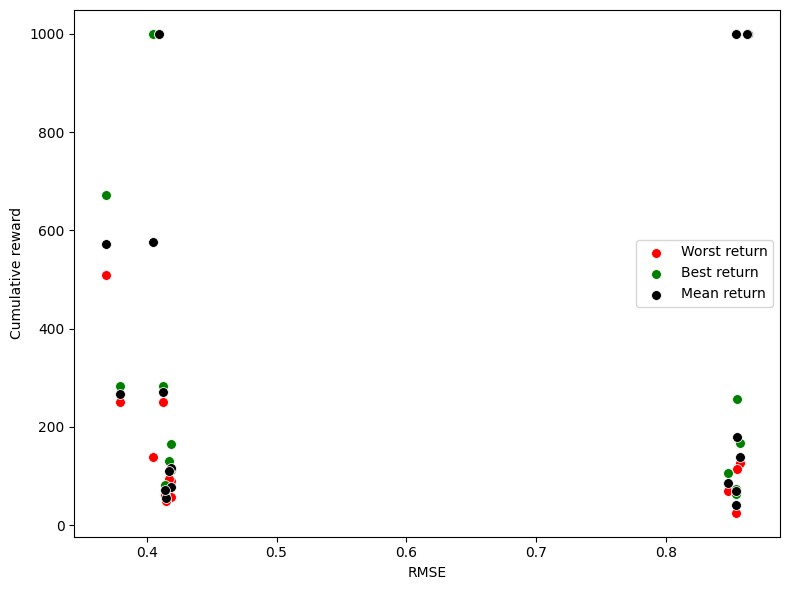

In [34]:
plt.figure(figsize=(8, 6))
# Worst return (red)
sns.scatterplot(
    data=df,
    x="best_fitness",
    y="worst_return",
    color="red",
    label="Worst return",
    s=50,
)

# Best return (green)
sns.scatterplot(
    data=df,
    x="best_fitness",
    y="best_return",
    color="green",
    label="Best return",
    s=50,
)

# Mean return (black)
sns.scatterplot(
    data=df,
    x="best_fitness",
    y="mean_return",
    color="black",
    label="Mean return",
    s=50,
)

plt.xlabel("RMSE")
plt.ylabel("Cumulative reward")
plt.legend()
plt.tight_layout()
plt.show()

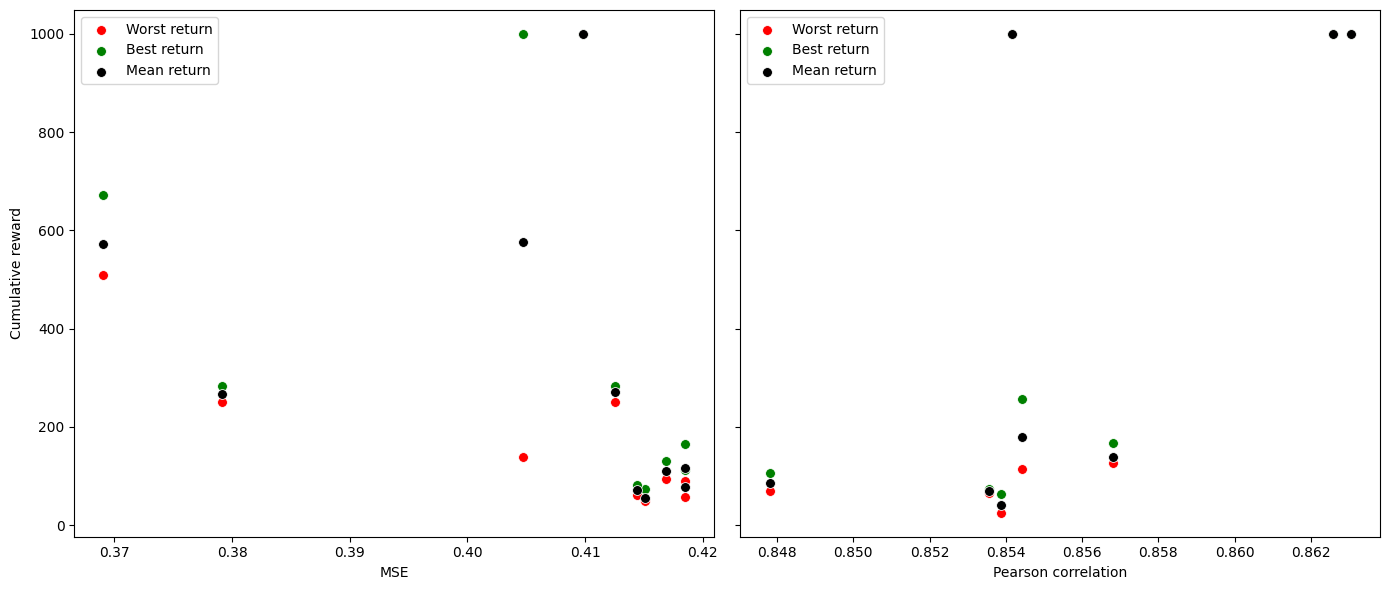

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

fitness_groups = ["MSE", "Pearson correlation"]

for ax, fitness_type in zip(axes, fitness_groups):
    subset = df[df["fitness"] == fitness_type]

    # Worst return
    sns.scatterplot(
        data=subset,
        x="best_fitness",
        y="worst_return",
        color="red",
        label="Worst return",
        s=50,
        ax=ax,
    )

    # Best return
    sns.scatterplot(
        data=subset,
        x="best_fitness",
        y="best_return",
        color="green",
        label="Best return",
        s=50,
        ax=ax,
    )

    # Mean return
    sns.scatterplot(
        data=subset,
        x="best_fitness",
        y="mean_return",
        color="black",
        label="Mean return",
        s=50,
        ax=ax,
    )

    ax.set_xlabel(fitness_type)
    ax.set_ylabel("Cumulative reward")
    ax.legend()

plt.tight_layout()
plt.show()

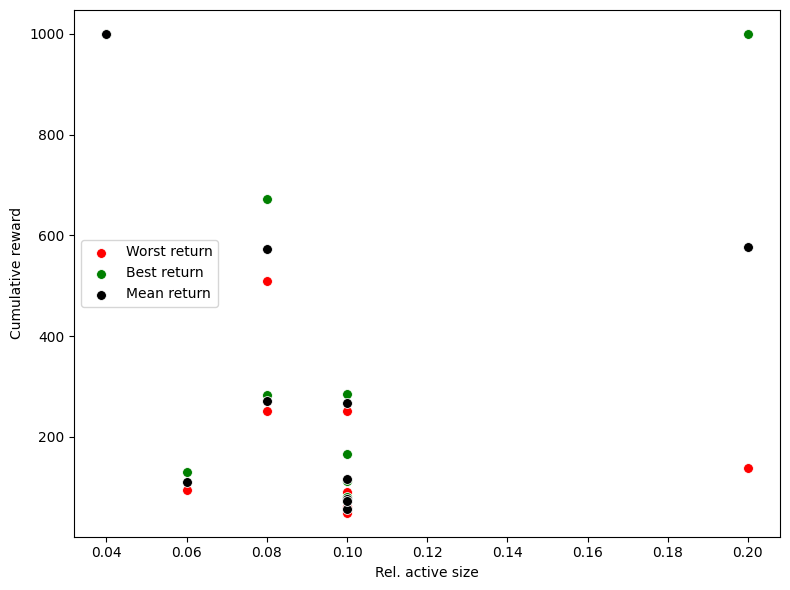

In [20]:
plt.figure(figsize=(8, 6))
# Worst return (red)
sns.scatterplot(
    data=df,
    x="active_size",
    y="worst_return",
    color="red",
    label="Worst return",
    s=50,
)

# Best return (green)
sns.scatterplot(
    data=df,
    x="active_size",
    y="best_return",
    color="green",
    label="Best return",
    s=50,
)

# Mean return (black)
sns.scatterplot(
    data=df,
    x="active_size",
    y="mean_return",
    color="black",
    label="Mean return",
    s=50,
)

plt.xlabel("Rel. active size")
plt.ylabel("Cumulative reward")
plt.legend()
plt.tight_layout()
plt.show()

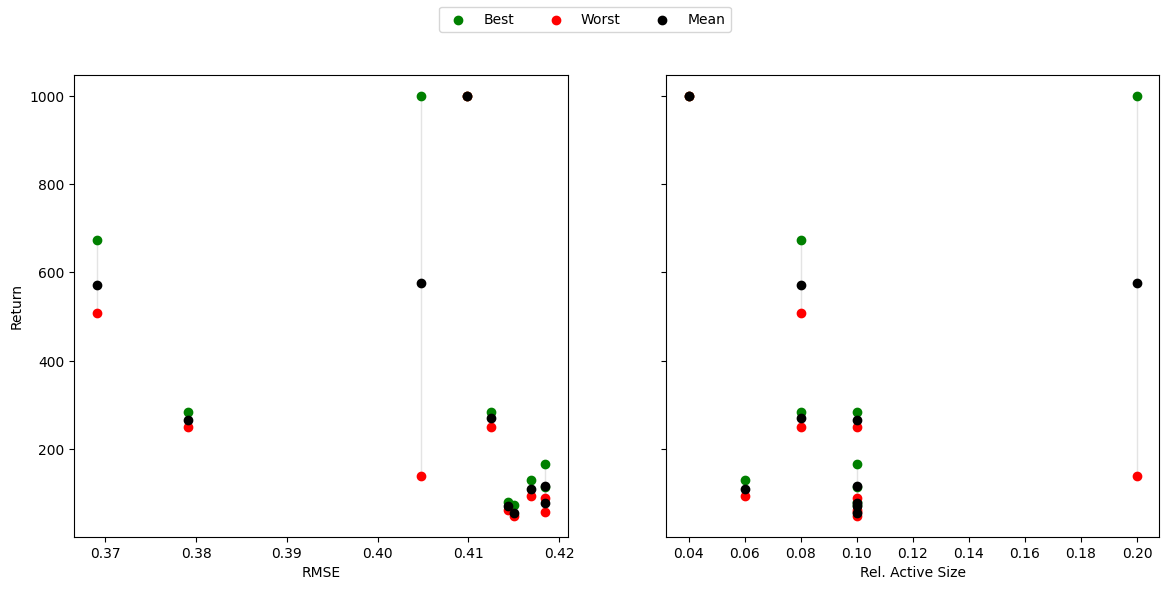

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

x_cols = ["best_fitness", "active_size"]
x_labels = ["RMSE", "Rel. Active Size"]  # whatever your second metric is

for ax, x_col, x_label in zip(axes, x_cols, x_labels):
    ax.vlines(
        x=df[x_col],
        ymin=df["worst_return"],
        ymax=df["best_return"],
        color="lightgray",
        linewidth=1,
        alpha=0.6,
    )

    ax.scatter(df[x_col], df["best_return"],
               color="green", label="Best", zorder=3)
    ax.scatter(df[x_col], df["worst_return"],
               color="red", label="Worst", zorder=3)
    ax.scatter(df[x_col], df["mean_return"],
               color="black", label="Mean", zorder=3)

    ax.set_xlabel(x_label)

axes[0].set_ylabel("Return")

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.show()

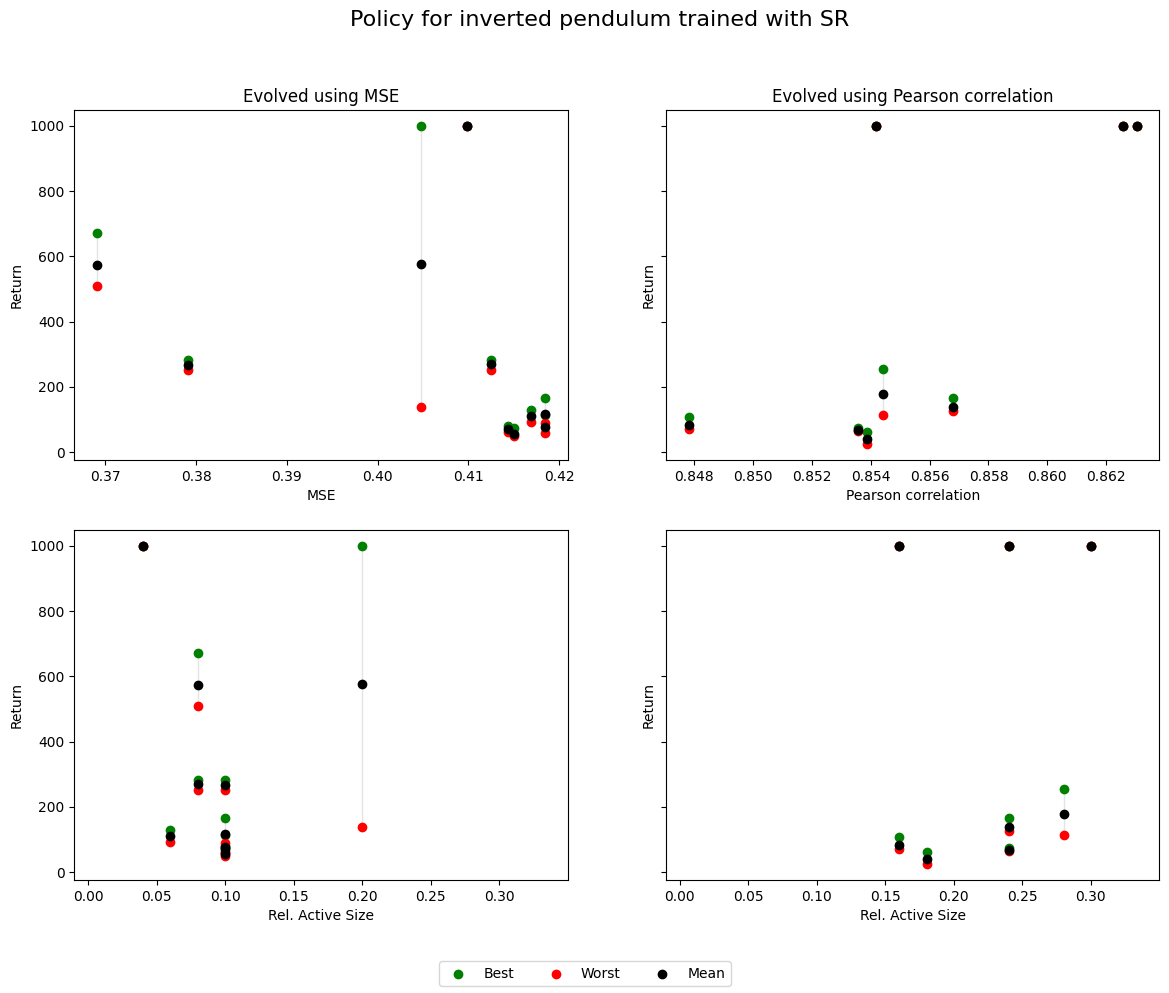

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

fitness_groups = ["MSE", "Pearson correlation"]
x_cols = ["best_fitness", "active_size"]
x_labels = ["best_fitness", "Rel. Active Size"]
xmin = df["active_size"].min() - 0.05
xmax = df["active_size"].max() + 0.05

axes[1, 0].set_xlim(xmin, xmax)
axes[1, 1].set_xlim(xmin, xmax)

for col, fitness_type in enumerate(fitness_groups):
    subset = df[df["fitness"] == fitness_type]

    for row, (x_col, x_label) in enumerate(zip(x_cols, x_labels)):
        ax = axes[row, col]

        ax.vlines(
            x=subset[x_col],
            ymin=subset["worst_return"],
            ymax=subset["best_return"],
            color="lightgray",
            linewidth=1,
            alpha=0.6,
        )

        ax.scatter(subset[x_col], subset["best_return"],
                   color="green", label="Best", zorder=3)
        ax.scatter(subset[x_col], subset["worst_return"],
                   color="red", label="Worst", zorder=3)
        ax.scatter(subset[x_col], subset["mean_return"],
                   color="black", label="Mean", zorder=3)

        if x_label == "best_fitness":
            ax.set_xlabel(fitness_type)
        else:
            ax.set_xlabel(x_label)

        ax.set_ylabel("Return")

        if row == 0:
            ax.set_title(f"Evolved using {fitness_type}")

        # if col == 0:
        #     ax.text(
        #         -0.15, 0.5, fitness_type,
        #         transform=ax.transAxes,
        #         rotation=90,
        #         va="center",
        #         ha="center",
        #         fontsize=12,
        #     )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
fig.suptitle(
    "Policy for inverted pendulum trained with SR",
    fontsize=16
)

plt.show()